# Manufacturing Quality & Production Dashboard

Exploratory Data Analysis using SQLite, SQL and Pandas.

In [137]:
import sqlite3
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt


DB_PATH = Path("../database/manufacturing.db")

IMAGES_PATH = Path("../images")
IMAGES_PATH.mkdir(exist_ok=True)

DATA_PROCESSED_PATH = Path("../data/processed")
DATA_PROCESSED_PATH.mkdir(parents=True, exist_ok=True)

In [138]:
DB_PATH.exists()

True

In [139]:
conn = sqlite3.connect(DB_PATH)

query = """
SELECT *
FROM production_records
LIMIT 5;
"""

sample_df = pd.read_sql_query(query, conn)

sample_df

,production_record_id,production_date,production_line_id,shift_id,product_id,produced_units,defective_units,downtime_minutes
0,1,2026-06-01,1,1,1,1000,35,42
1,2,2026-06-02,1,1,1,1201,24,34
2,3,2026-06-03,1,1,1,1148,26,17
3,4,2026-06-03,1,2,3,1146,32,31
4,5,2026-06-03,1,3,3,930,33,29


In [140]:
def read_query(query):
    with sqlite3.connect(DB_PATH) as conn:
        return pd.read_sql_query(query, conn)

In [141]:
query = """
SELECT *
FROM production_records
LIMIT 5;
"""

read_query(query)

,production_record_id,production_date,production_line_id,shift_id,product_id,produced_units,defective_units,downtime_minutes
0,1,2026-06-01,1,1,1,1000,35,42
1,2,2026-06-02,1,1,1,1201,24,34
2,3,2026-06-03,1,1,1,1148,26,17
3,4,2026-06-03,1,2,3,1146,32,31
4,5,2026-06-03,1,3,3,930,33,29


## Load production data

In [142]:
query = """
SELECT
    pr.production_record_id,
    pr.production_date,
    pl.line_name,
    sh.shift_name,
    pd.product_name,
    pd.appliance_type,
    pr.produced_units,
    pr.defective_units,
    ROUND(pr.defective_units * 100.0 / pr.produced_units, 2) AS defect_rate_percent,
    pr.downtime_minutes
FROM production_records AS pr
JOIN production_lines AS pl
    ON pr.production_line_id = pl.production_line_id
JOIN shifts AS sh
    ON pr.shift_id = sh.shift_id
JOIN products AS pd
    ON pr.product_id = pd.product_id;
"""

production_df = read_query(query)

production_df.head()

,production_record_id,production_date,line_name,shift_name,product_name,appliance_type,produced_units,defective_units,defect_rate_percent,downtime_minutes
0,1,2026-06-01,Line 1,Morning,Washing Machine Control Board,Washing Machine,1000,35,3.50,42
1,2,2026-06-02,Line 1,Morning,Washing Machine Control Board,Washing Machine,1201,24,2.00,34
2,3,2026-06-03,Line 1,Morning,Washing Machine Control Board,Washing Machine,1148,26,2.26,17
3,4,2026-06-03,Line 1,Afternoon,Refrigerator Control Board,Refrigerator,1146,32,2.79,31
4,5,2026-06-03,Line 1,Night,Refrigerator Control Board,Refrigerator,930,33,3.55,29


In [143]:
production_df.shape

(338, 10)

In [144]:
production_df.columns

Index(['production_record_id', 'production_date', 'line_name', 'shift_name',
       'product_name', 'appliance_type', 'produced_units', 'defective_units',
       'defect_rate_percent', 'downtime_minutes'],
      dtype='str')

In [145]:
production_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 338 entries, 0 to 337
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   production_record_id  338 non-null    int64  
 1   production_date       338 non-null    str    
 2   line_name             338 non-null    str    
 3   shift_name            338 non-null    str    
 4   product_name          338 non-null    str    
 5   appliance_type        338 non-null    str    
 6   produced_units        338 non-null    int64  
 7   defective_units       338 non-null    int64  
 8   defect_rate_percent   338 non-null    float64
 9   downtime_minutes      338 non-null    int64  
dtypes: float64(1), int64(4), str(5)
memory usage: 26.5 KB


In [146]:
production_df.isnull().sum()

production_record_id    0
production_date         0
line_name               0
shift_name              0
product_name            0
appliance_type          0
produced_units          0
defective_units         0
defect_rate_percent     0
downtime_minutes        0
dtype: int64

In [147]:
production_df["production_date"] = pd.to_datetime(production_df["production_date"])

In [148]:
production_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 338 entries, 0 to 337
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   production_record_id  338 non-null    int64         
 1   production_date       338 non-null    datetime64[us]
 2   line_name             338 non-null    str           
 3   shift_name            338 non-null    str           
 4   product_name          338 non-null    str           
 5   appliance_type        338 non-null    str           
 6   produced_units        338 non-null    int64         
 7   defective_units       338 non-null    int64         
 8   defect_rate_percent   338 non-null    float64       
 9   downtime_minutes      338 non-null    int64         
dtypes: datetime64[us](1), float64(1), int64(4), str(4)
memory usage: 26.5 KB


In [149]:
total_produced_units = production_df["produced_units"].sum()
total_defective_units = production_df["defective_units"].sum()
overall_defect_rate = total_defective_units * 100 / total_produced_units
total_downtime_minutes = production_df["downtime_minutes"].sum()
total_production_records = production_df["production_record_id"].count()

print("Total produced units:", total_produced_units)
print("Total defective units:", total_defective_units)
print("Overall defect rate:", round(overall_defect_rate, 2))
print("Total downtime minutes:", total_downtime_minutes)
print("Total production records:", total_production_records)

Total produced units: 295163
Total defective units: 12667
Overall defect rate: 4.29
Total downtime minutes: 14635
Total production records: 338


### Overall KPI validation

The overall KPIs calculated with Pandas match the SQL results.

- Total produced units: 295,163
- Total defective units: 12,667
- Overall defect rate: 4.29%
- Total downtime minutes: 14,635
- Total production records: 338

This confirms that the dataset was loaded correctly from SQLite and is ready for exploratory analysis.

## Analysis by production line

In [150]:
line_summary = (
    production_df
    .groupby("line_name")
    .agg(
        total_produced_units=("produced_units", "sum"),
        total_defective_units=("defective_units", "sum"),
        total_downtime_minutes=("downtime_minutes", "sum")
    )
    .reset_index()
)

line_summary["defect_rate_percent"] = (
    line_summary["total_defective_units"] * 100 / line_summary["total_produced_units"]
).round(2)

line_summary = line_summary.sort_values("defect_rate_percent", ascending=False)

line_summary

,line_name,total_produced_units,total_defective_units,total_downtime_minutes,defect_rate_percent
3,Line 4,53373,3331,3810,6.24
1,Line 2,78097,3918,3304,5.02
2,Line 3,69939,2767,5002,3.96
0,Line 1,93754,2651,2519,2.83


### Production line findings

Line 4 has the highest defect rate at 6.24%, indicating the worst proportional quality performance.

Line 2 has the highest total defective units, while Line 3 has the highest accumulated downtime.

This shows why analyzing both totals and rates is important: the line with the highest number of defects is not necessarily the line with the worst defect rate.

## Analysis by shift

In [151]:
shift_summary = (
    production_df
    .groupby("shift_name")
    .agg(
        total_produced_units=("produced_units", "sum"),
        total_defective_units=("defective_units", "sum"),
        total_downtime_minutes=("downtime_minutes", "sum")
    )
    .reset_index()
)

shift_summary["defect_rate_percent"] = (
    shift_summary["total_defective_units"] * 100 / shift_summary["total_produced_units"]
).round(2)

shift_summary = shift_summary.sort_values("defect_rate_percent", ascending=False)

shift_summary

,shift_name,total_produced_units,total_defective_units,total_downtime_minutes,defect_rate_percent
2,Night,89085,4678,5845,5.25
0,Afternoon,99237,4237,4641,4.27
1,Morning,106841,3752,4149,3.51


### Shift findings

Night shift has the worst operational performance, with the highest defect rate and highest accumulated downtime.

Morning shift performs best, with the highest production volume, lowest defect rate and lowest downtime.

This suggests that night shift operations may require additional review, such as staffing, supervision, maintenance availability or process control.

## Analysis by product

In [152]:
product_summary = (
    production_df
    .groupby(["product_name", "appliance_type"])
    .agg(
        total_produced_units=("produced_units", "sum"),
        total_defective_units=("defective_units", "sum"),
        total_downtime_minutes=("downtime_minutes", "sum")
    )
    .reset_index()
)

product_summary["defect_rate_percent"] = (
    product_summary["total_defective_units"] * 100 / product_summary["total_produced_units"]
).round(2)

product_summary = product_summary.sort_values("defect_rate_percent", ascending=False)

product_summary

,product_name,appliance_type,total_produced_units,total_defective_units,total_downtime_minutes,defect_rate_percent
1,Refrigerator Control Board,Refrigerator,109747,5059,5308,4.61
0,Oven Control Board,Oven,82951,3491,4034,4.21
2,Washing Machine Control Board,Washing Machine,102465,4117,5293,4.02


### Product findings

Refrigerator Control Board has the highest defect rate among the analyzed products.

Although all products show similar defect rates, refrigerator boards have the worst proportional quality performance, which suggests that this product may require additional review in programming, testing or process validation.

## Analysis by defect type

In [153]:
query = """
SELECT  
    dt.defect_name AS defect_name,
    SUM(dr.defect_quantity) AS total_defect_units
FROM defect_records AS dr
JOIN defect_types AS dt
    ON dr.defect_type_id = dt.defect_type_id
GROUP BY dt.defect_type_id, dt.defect_name
ORDER BY total_defect_units DESC;
"""

defect_summary = read_query(query)

defect_summary

,defect_name,total_defect_units
0,Defective soldering,4583
1,Programming error,3414
2,Missing component,2605
3,Physical damage,2065


### Defect type findings

Defective soldering is the most frequent defect type, with 4,583 recorded defects.

This suggests that soldering quality is the main area to review in the production process. Possible improvement actions could include checking soldering parameters, inspection criteria, operator training and equipment calibration.

## Defect types by product

In [154]:
query = """
SELECT  
    pd.product_name AS product_name,
    dt.defect_name AS defect_name,    
    SUM(dr.defect_quantity) AS total_defect_units
FROM defect_records AS dr
JOIN defect_types AS dt
    ON dr.defect_type_id = dt.defect_type_id
JOIN production_records AS pr
    ON dr.production_record_id = pr.production_record_id
JOIN products AS pd
    ON pr.product_id = pd.product_id
GROUP BY 
    pd.product_id,
    pd.product_name,
    dt.defect_type_id,
    dt.defect_name
ORDER BY total_defect_units DESC;
"""

defects_by_product_df = read_query(query)

defects_by_product_df

,product_name,defect_name,total_defect_units
0,Washing Machine Control Board,Defective soldering,1999
1,Refrigerator Control Board,Programming error,1977
2,Refrigerator Control Board,Defective soldering,1417
3,Oven Control Board,Defective soldering,1167
4,Oven Control Board,Physical damage,1004
5,Washing Machine Control Board,Missing component,983
6,Refrigerator Control Board,Missing component,962
7,Washing Machine Control Board,Programming error,777
8,Refrigerator Control Board,Physical damage,703
9,Oven Control Board,Missing component,660


### Defect types by product findings

The most frequent product-defect combination is Washing Machine Control Board with Defective soldering.

Refrigerator Control Board shows a strong concentration of Programming error defects, which aligns with its higher overall defect rate.

Oven Control Board shows relevant issues in both Defective soldering and Physical damage.

This suggests that improvement actions should be product-specific instead of applying the same quality action to all production lines and products.

## Daily production trend

In [155]:
daily_summary = (
    production_df
    .groupby("production_date")
    .agg(
        total_produced_units=("produced_units", "sum"),
        total_defective_units=("defective_units", "sum"),
        total_downtime_minutes=("downtime_minutes", "sum")
    )
    .reset_index()
)

daily_summary["defect_rate_percent"] = (
    daily_summary["total_defective_units"] * 100 / daily_summary["total_produced_units"]
).round(2)

daily_summary = daily_summary.sort_values("production_date")

daily_summary.head()

,production_date,total_produced_units,total_defective_units,total_downtime_minutes,defect_rate_percent
0,2026-06-01,1000,35,42,3.50
1,2026-06-02,1201,24,34,2.00
2,2026-06-03,10349,451,490,4.36
3,2026-06-04,10378,445,538,4.29
4,2026-06-05,10537,440,473,4.18


### Daily trend findings

In [156]:
daily_summary.sort_values("defect_rate_percent", ascending=False).head(5)

,production_date,total_produced_units,total_defective_units,total_downtime_minutes,defect_rate_percent
11,2026-06-12,10427,485,528,4.65
15,2026-06-16,10761,485,538,4.51
24,2026-06-25,10631,478,477,4.50
6,2026-06-07,10657,480,514,4.50
13,2026-06-14,10592,469,498,4.43


In [157]:
daily_summary.sort_values("total_downtime_minutes", ascending=False).head(5)

,production_date,total_produced_units,total_defective_units,total_downtime_minutes,defect_rate_percent
26,2026-06-27,10311,452,562,4.38
20,2026-06-21,10427,429,558,4.11
21,2026-06-22,10323,443,558,4.29
17,2026-06-18,10488,441,556,4.20
28,2026-06-29,10536,450,547,4.27


The worst daily defect rate occurred on 2026-06-12, with a defect rate of 4.65%.

However, the highest downtime occurred on 2026-06-27, with 562 downtime minutes and a defect rate of 4.38%.

This suggests that downtime may be related to quality issues, but it is not the only factor explaining defect rates. Other factors such as production line, shift, product type or defect category should also be considered.

## Daily defect rate visualization

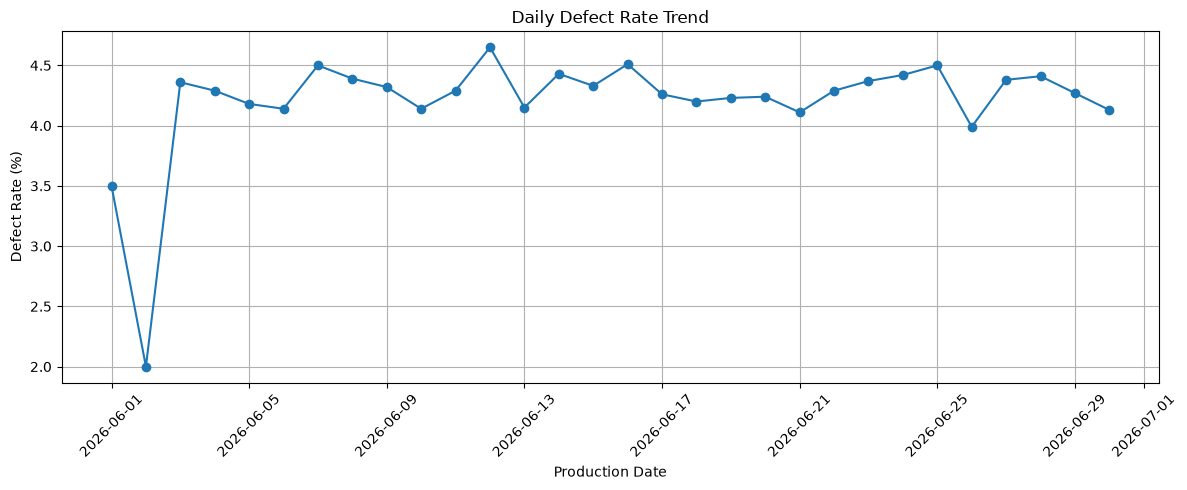

In [158]:
plt.figure(figsize=(12, 5))

plt.plot(
    daily_summary["production_date"],
    daily_summary["defect_rate_percent"],
    marker="o"
)

plt.title("Daily Defect Rate Trend")
plt.xlabel("Production Date")
plt.ylabel("Defect Rate (%)")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

plt.show()

In [159]:
daily_summary_clean = daily_summary[
    daily_summary["production_date"] >= pd.to_datetime("2026-06-03")
].copy()

daily_summary_clean.head()

,production_date,total_produced_units,total_defective_units,total_downtime_minutes,defect_rate_percent
2,2026-06-03,10349,451,490,4.36
3,2026-06-04,10378,445,538,4.29
4,2026-06-05,10537,440,473,4.18
5,2026-06-06,10531,436,528,4.14
6,2026-06-07,10657,480,514,4.50


### Clean daily defect rate trend

The first two dates were excluded from this visualization because they were test records created before generating the complete simulated dataset.

From 2026-06-03 onward, each day contains a complete production structure with all lines and shifts.

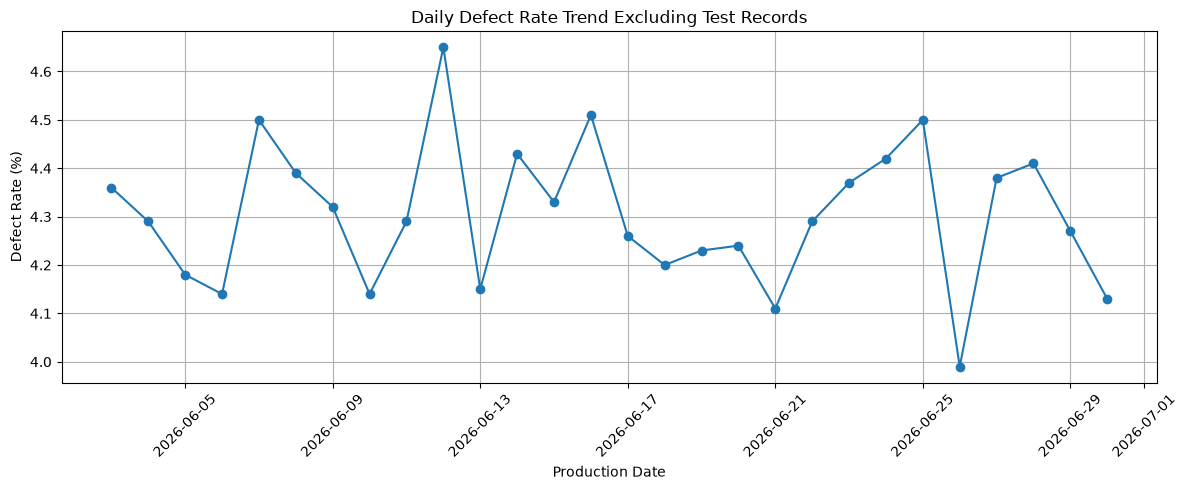

In [160]:
plt.figure(figsize=(12, 5))

plt.plot(
    daily_summary_clean["production_date"],
    daily_summary_clean["defect_rate_percent"],
    marker="o"
)

plt.title("Daily Defect Rate Trend Excluding Test Records")
plt.xlabel("Production Date")
plt.ylabel("Defect Rate (%)")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

plt.savefig(IMAGES_PATH / "daily_defect_rate_trend_etr.png", dpi=300, bbox_inches="tight")

plt.show()

## Downtime vs defect rate

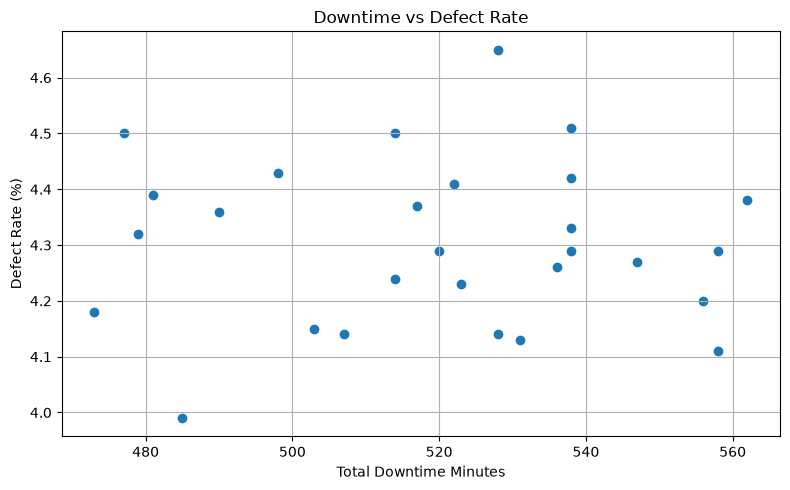

In [161]:
plt.figure(figsize=(8, 5))

plt.scatter(
    daily_summary_clean["total_downtime_minutes"],
    daily_summary_clean["defect_rate_percent"]
)

plt.title("Downtime vs Defect Rate")
plt.xlabel("Total Downtime Minutes")
plt.ylabel("Defect Rate (%)")
plt.grid(True)
plt.tight_layout()

plt.savefig(IMAGES_PATH / "downtime_vs_defect_rate.png", dpi=300, bbox_inches="tight")

plt.show()

In [162]:
correlation = daily_summary_clean["total_downtime_minutes"].corr(
    daily_summary_clean["defect_rate_percent"]
)

print(f"Correlation between downtime and defect rate: {correlation:.2f}")

Correlation between downtime and defect rate: -0.01


### Downtime vs defect rate findings

The correlation between total downtime minutes and defect rate is -0.01, which is almost zero.

This indicates that daily downtime does not have a meaningful linear relationship with the daily defect rate in this dataset.

Although downtime is an important operational KPI, the defect rate appears to be influenced more by other factors such as production line, shift, product type or defect category.

## Defect rate by production line

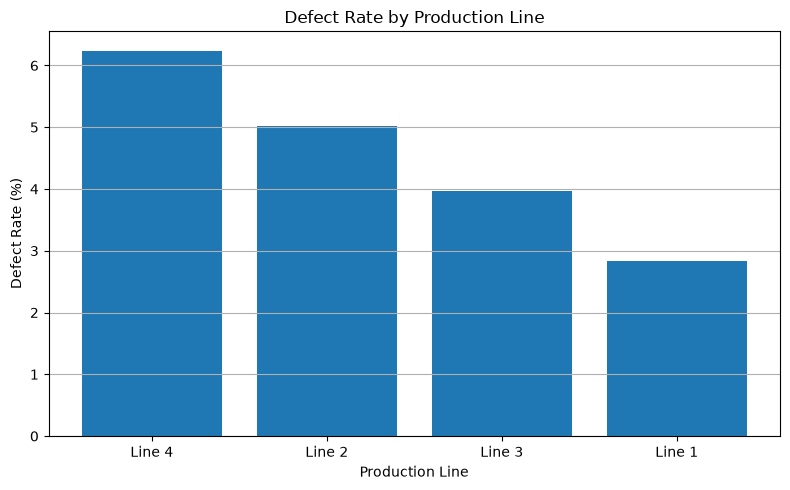

In [163]:
plt.figure(figsize=(8, 5))

plt.bar(
    line_summary["line_name"],
    line_summary["defect_rate_percent"]
)

plt.title("Defect Rate by Production Line")
plt.xlabel("Production Line")
plt.ylabel("Defect Rate (%)")
plt.grid(axis="y")
plt.tight_layout()

plt.savefig(IMAGES_PATH / "defect_rate_by_line.png", dpi=300, bbox_inches="tight")

plt.show()

### Defect rate by production line findings

Line 4 has the highest defect rate, at 6.24%, making it the worst-performing production line in terms of proportional quality.

Line 1 has the lowest defect rate, at 2.83%, making it the best-performing line.

This confirms that Line 4 should be prioritized for quality improvement actions.

## Defect rate by shift

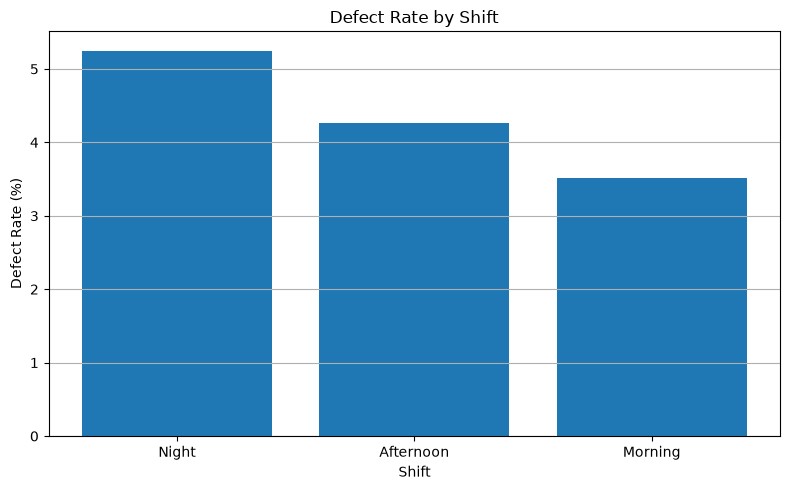

In [164]:
plt.figure(figsize=(8, 5))

plt.bar(
    shift_summary["shift_name"],
    shift_summary["defect_rate_percent"]
)

plt.title("Defect Rate by Shift")
plt.xlabel("Shift")
plt.ylabel("Defect Rate (%)")
plt.grid(axis="y")
plt.tight_layout()

plt.savefig(IMAGES_PATH / "defect_rate_by_shift.png", dpi=300, bbox_inches="tight")

plt.show()

### Defect rate by shift findings

Night shift has the highest defect rate, making it the worst-performing shift in terms of quality.

Morning shift has the lowest defect rate, which suggests better process stability during that shift.

This indicates that night shift operations should be reviewed, especially around staffing, supervision, machine availability and process control.

## Defect rate by product

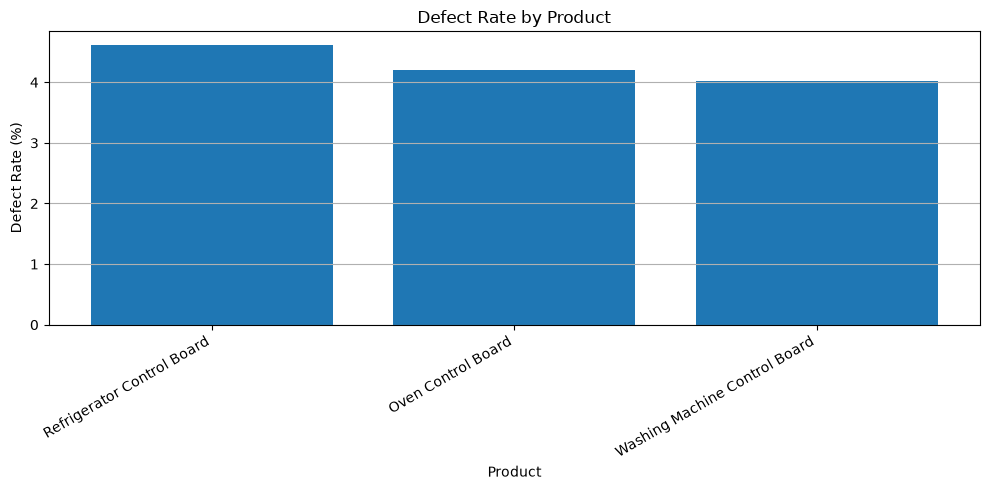

In [165]:
plt.figure(figsize=(10, 5))

plt.bar(
    product_summary["product_name"],
    product_summary["defect_rate_percent"]
)

plt.title("Defect Rate by Product")
plt.xlabel("Product")
plt.ylabel("Defect Rate (%)")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y")
plt.tight_layout()

plt.savefig(IMAGES_PATH / "defect_rate_by_product.png", dpi=300, bbox_inches="tight")

plt.show()

### Defect rate by product findings

Refrigerator Control Board has the highest defect rate among the analyzed products.

Although the defect rates are relatively close across products, refrigerator boards show the worst proportional quality performance.

This supports the previous finding that Refrigerator Control Board should be reviewed, especially around programming errors and testing validation.

## Defects by defect type

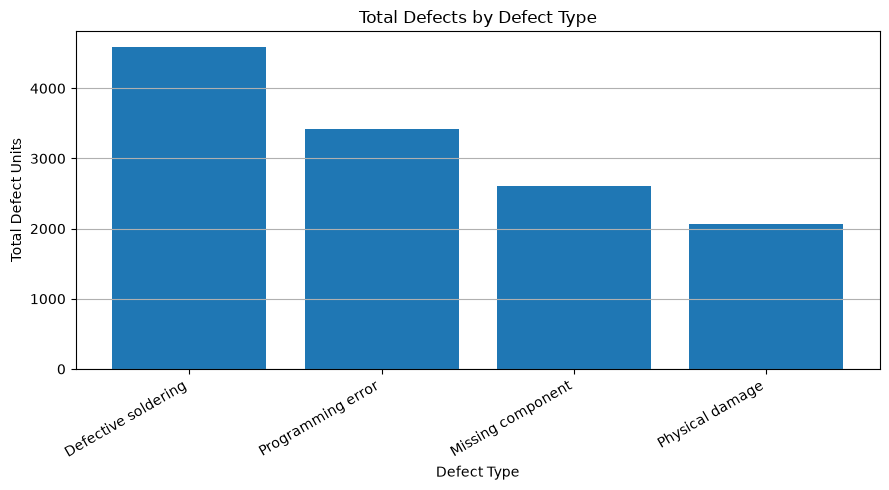

In [166]:
plt.figure(figsize=(9, 5))

plt.bar(
    defect_summary["defect_name"],
    defect_summary["total_defect_units"]
)

plt.title("Total Defects by Defect Type")
plt.xlabel("Defect Type")
plt.ylabel("Total Defect Units")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y")
plt.tight_layout()

plt.savefig(IMAGES_PATH / "defects_by_type.png", dpi=300, bbox_inches="tight")

plt.show()

### Defects by defect type findings

Defective soldering is the most frequent defect type, with 4,583 recorded defects.

Programming error is the second most common defect type, followed by Missing component and Physical damage.

This suggests that soldering quality should be the first improvement priority in the production process.

## Defect types by product visualization

In [167]:
defects_by_product_pivot = defects_by_product_df.pivot(
    index="product_name",
    columns="defect_name",
    values="total_defect_units"
).fillna(0)

defects_by_product_pivot

defect_name,Defective soldering,Missing component,Physical damage,Programming error
product_name,,,,
Oven Control Board,1167,660,1004,660
Refrigerator Control Board,1417,962,703,1977
Washing Machine Control Board,1999,983,358,777


<Figure size 1000x600 with 0 Axes>

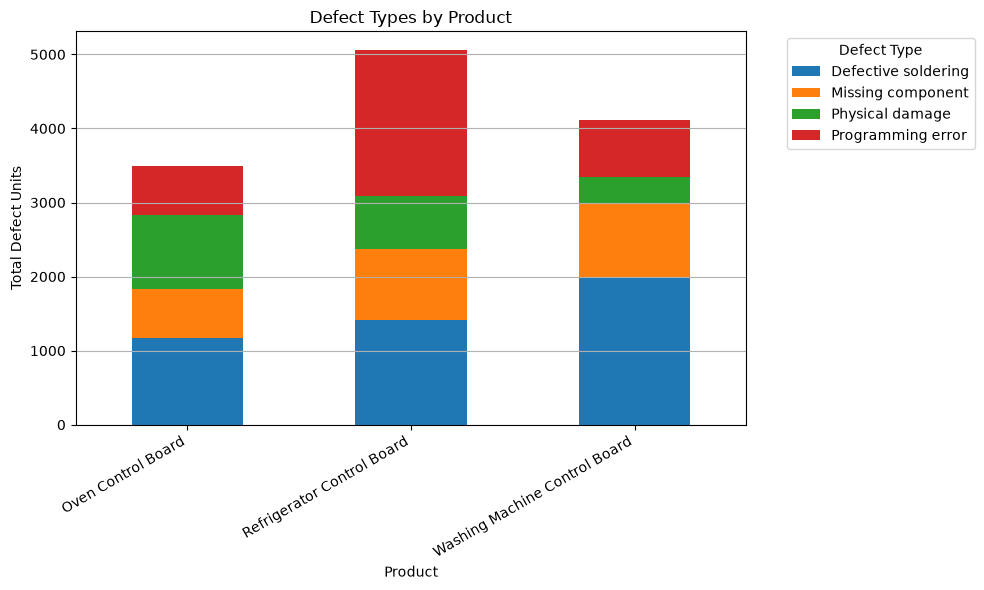

In [168]:
plt.figure(figsize=(10, 6))

defects_by_product_pivot.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.title("Defect Types by Product")
plt.xlabel("Product")
plt.ylabel("Total Defect Units")
plt.xticks(rotation=30, ha="right")
plt.legend(title="Defect Type", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(axis="y")
plt.tight_layout()

plt.savefig(IMAGES_PATH / "defect_types_by_product.png", dpi=300, bbox_inches="tight")

plt.show()

### Defect types by product visualization findings

The stacked bar chart shows the total number of defects for each product, split by defect type.

Refrigerator Control Board has the highest total number of defects, with Programming error as its largest contributor.

Washing Machine Control Board is mainly affected by Defective soldering.

Oven Control Board shows a more balanced distribution, with Defective soldering and Physical damage as the most relevant defect types.

## Defect type percentage by product

In [169]:
defects_by_product_percent = defects_by_product_pivot.div(
    defects_by_product_pivot.sum(axis=1),
    axis=0
) * 100

defects_by_product_percent = defects_by_product_percent.round(2)

defects_by_product_percent

defect_name,Defective soldering,Missing component,Physical damage,Programming error
product_name,,,,
Oven Control Board,33.43,18.91,28.76,18.91
Refrigerator Control Board,28.01,19.02,13.90,39.08
Washing Machine Control Board,48.55,23.88,8.70,18.87


<Figure size 1000x600 with 0 Axes>

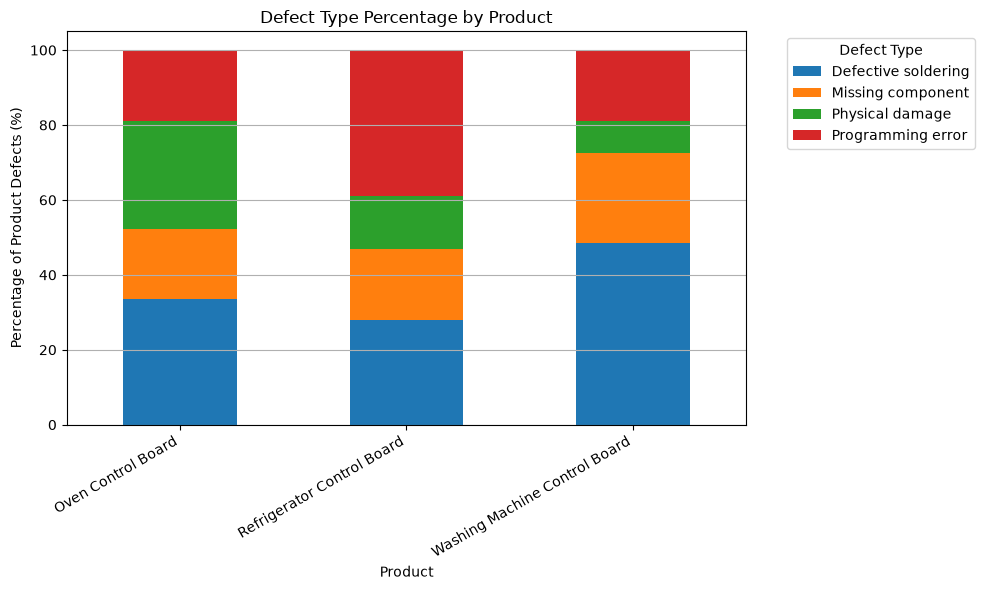

In [170]:
plt.figure(figsize=(10, 6))

defects_by_product_percent.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.title("Defect Type Percentage by Product")
plt.xlabel("Product")
plt.ylabel("Percentage of Product Defects (%)")
plt.xticks(rotation=30, ha="right")
plt.legend(title="Defect Type", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(axis="y")
plt.tight_layout()

plt.savefig(IMAGES_PATH / "defect_type_percentage_by_product.png", dpi=300, bbox_inches="tight")

plt.show()

### Defect type percentage by product findings

The percentage stacked bar chart shows the internal defect composition of each product.

Washing Machine Control Board has the highest proportion of Defective soldering defects.

Refrigerator Control Board has the highest proportion of Programming error defects.

Oven Control Board has a more balanced distribution, with Defective soldering and Physical damage as the most relevant categories.

This confirms that quality improvement actions should be product-specific instead of using the same corrective action for all products.


## Export processed datasets

In [171]:
production_df.to_csv(DATA_PROCESSED_PATH / "production_data.csv", index=False)
line_summary.to_csv(DATA_PROCESSED_PATH / "line_summary.csv", index=False)
shift_summary.to_csv(DATA_PROCESSED_PATH / "shift_summary.csv", index=False)
product_summary.to_csv(DATA_PROCESSED_PATH / "product_summary.csv", index=False)
defect_summary.to_csv(DATA_PROCESSED_PATH / "defect_summary.csv", index=False)
defects_by_product_df.to_csv(DATA_PROCESSED_PATH / "defects_by_product.csv", index=False)
daily_summary_clean.to_csv(DATA_PROCESSED_PATH / "daily_summary_clean.csv", index=False)

print("Processed datasets exported successfully.")

Processed datasets exported successfully.
